In [28]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

import plotly.express as px

In [4]:
df = pd.read_csv("../data/processed/creditcard_clean.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 283726
Columns : 31


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283726 entries, 0 to 283725
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     28

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,283726.0,94811.077600,47481.047891,0.000000,54204.750000,84692.500000,139298.000000,172792.000000
V1,283726.0,0.005917,1.948026,-56.407510,-0.915951,0.020384,1.316068,2.454930
V2,283726.0,-0.004135,1.646703,-72.715728,-0.600321,0.063949,0.800283,22.057729
V3,283726.0,0.001613,1.508682,-48.325589,-0.889682,0.179963,1.026960,9.382558
V4,283726.0,-0.002966,1.414184,-5.683171,-0.850134,-0.022248,0.739647,16.875344
V5,283726.0,0.001828,1.377008,-113.743307,-0.689830,-0.053468,0.612218,34.801666
V6,283726.0,-0.001139,1.331931,-26.160506,-0.769031,-0.275168,0.396792,73.301626
V7,283726.0,0.001801,1.227664,-43.557242,-0.552509,0.040859,0.570474,120.589494
V8,283726.0,-0.000854,1.179054,-73.216718,-0.208828,0.021898,0.325704,20.007208
V9,283726.0,-0.001596,1.095492,-13.434066,-0.644221,-0.052596,0.595977,15.594995


In [8]:
missing = df.isnull().sum()

missing

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [9]:
missing.sum()

0

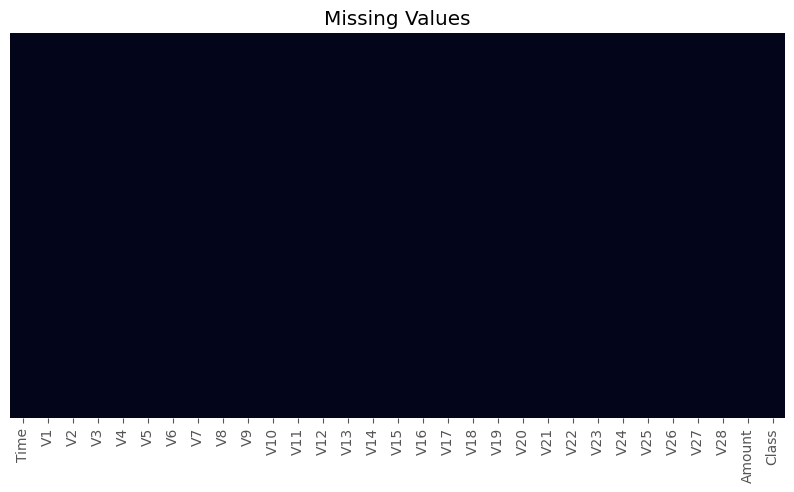

In [10]:
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(),
            cbar=False,
            yticklabels=False)

plt.title("Missing Values")

plt.savefig("../images/missing_values.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [11]:
duplicates = df.duplicated().sum()

print(duplicates)

0


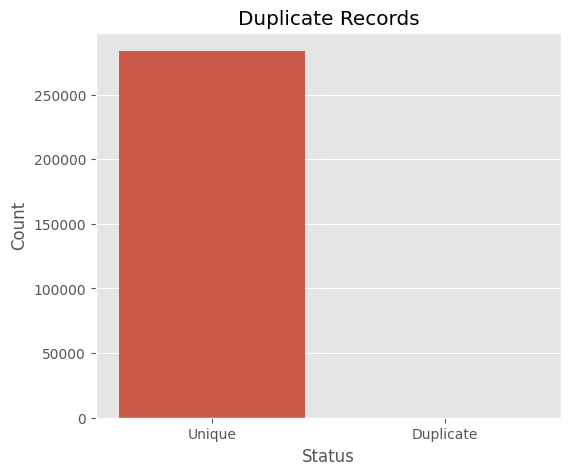

In [12]:
duplicate_df = pd.DataFrame({
    "Status":["Unique","Duplicate"],
    "Count":[len(df)-duplicates,duplicates]
})

plt.figure(figsize=(6,5))

sns.barplot(data=duplicate_df,
            x="Status",
            y="Count")

plt.title("Duplicate Records")

plt.savefig("../images/duplicate_records.png",
            dpi=300)

plt.show()

In [13]:
df["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [14]:
df["Class"].value_counts(normalize=True)*100

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

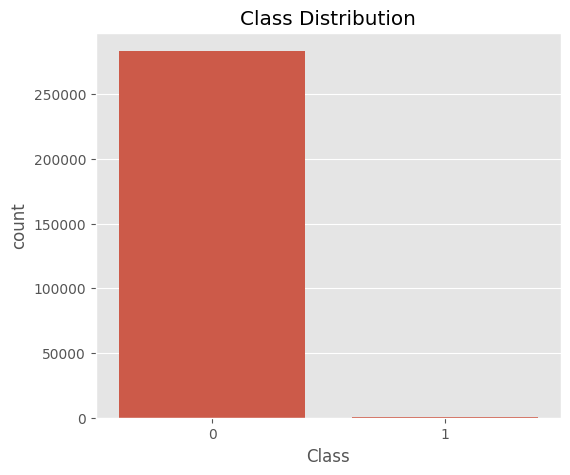

In [15]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,
              x="Class")

plt.title("Class Distribution")

plt.savefig("../images/class_distribution.png",
            dpi=300)

plt.show()

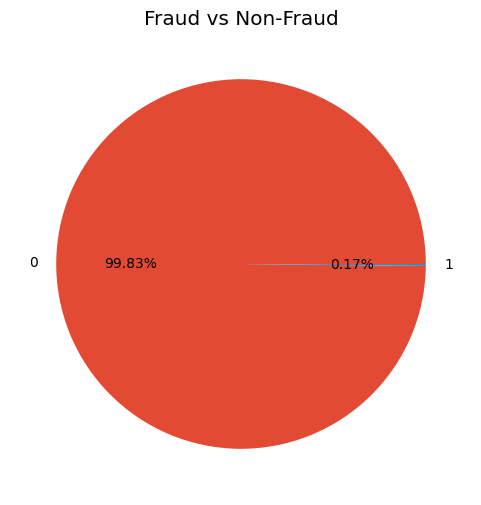

In [16]:
plt.figure(figsize=(6,6))

df["Class"].value_counts().plot(
    kind="pie",
    autopct="%1.2f%%"
)

plt.ylabel("")

plt.title("Fraud vs Non-Fraud")

plt.show()

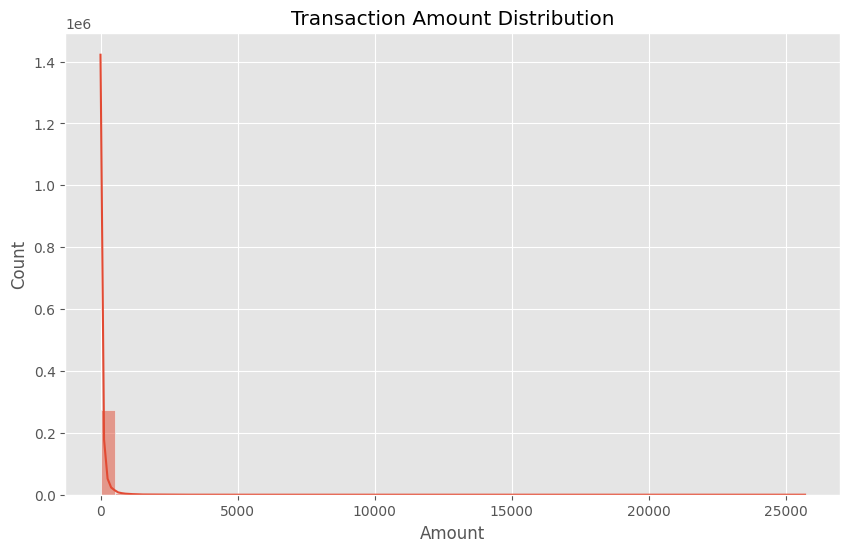

In [17]:
plt.figure(figsize=(10,6))

sns.histplot(df["Amount"],
             bins=50,
             kde=True)

plt.title("Transaction Amount Distribution")

plt.savefig("../images/amount_distribution.png",
            dpi=300)

plt.show()

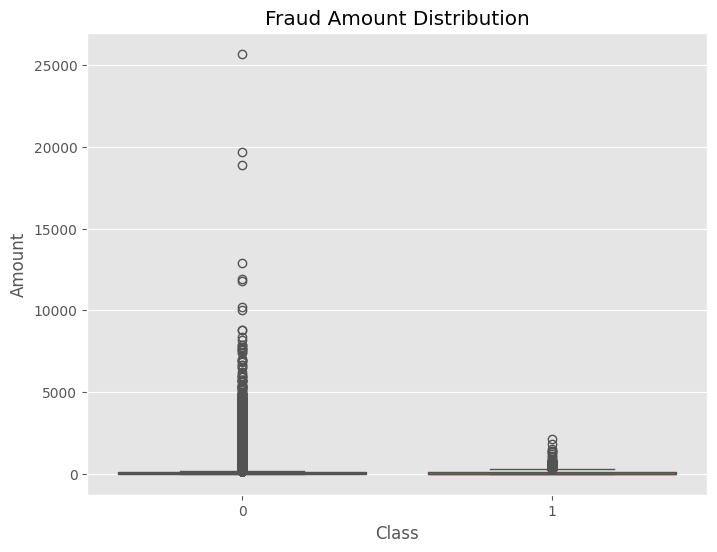

In [18]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="Class",
    y="Amount",
    data=df
)

plt.title("Fraud Amount Distribution")

plt.savefig("../images/fraud_amount_boxplot.png",
            dpi=300)

plt.show()

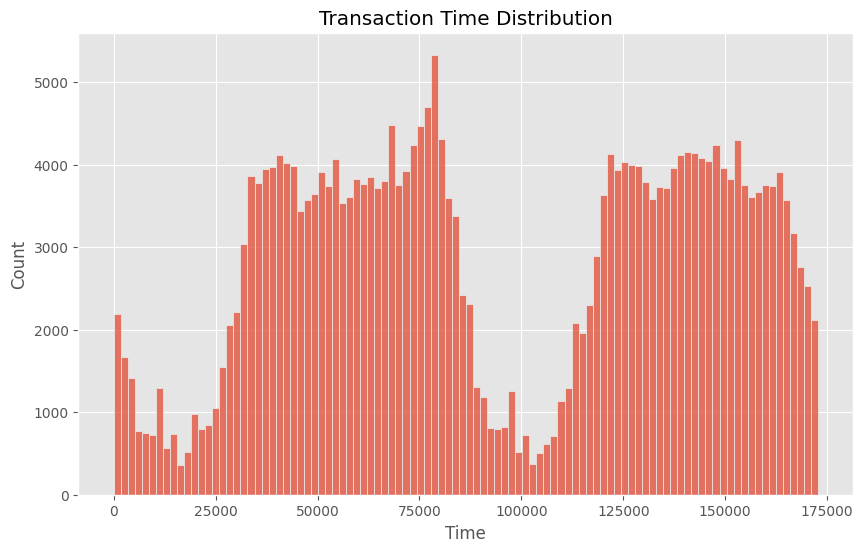

In [19]:
plt.figure(figsize=(10,6))

sns.histplot(df["Time"],
             bins=100)

plt.title("Transaction Time Distribution")

plt.savefig("../images/time_distribution.png",
            dpi=300)

plt.show()

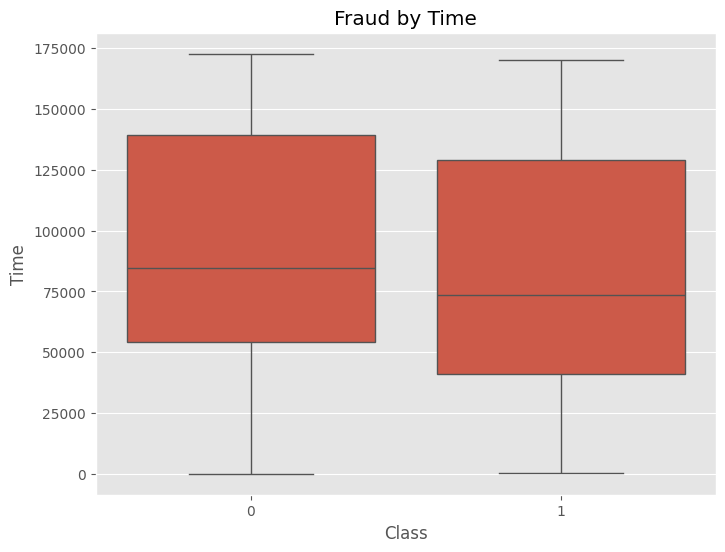

In [20]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="Class",
    y="Time",
    data=df
)

plt.title("Fraud by Time")

plt.savefig("../images/fraud_time_boxplot.png",
            dpi=300)

plt.show()

In [21]:
corr = df.corr()

corr.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,0.117927,-0.010556,-0.422054,-0.105845,0.173223,-0.063279,0.085335,-0.038203,-0.007861,...,0.045913,0.143727,0.051474,-0.015954,-0.233262,-0.041818,-0.005171,-0.009305,-0.010559,-0.012359
V1,0.117927,1.000000,0.006875,-0.008112,0.002257,-0.007036,0.000413,-0.009173,-0.001168,0.001828,...,0.002818,-0.001436,-0.001330,-0.000723,-0.000222,-0.000684,-0.015706,-0.004861,-0.230105,-0.094486
V2,-0.010556,0.006875,1.000000,0.005278,-0.001495,0.005210,-0.000594,0.007425,0.002899,-0.000274,...,-0.004897,0.001237,-0.003855,0.000701,-0.001569,0.000253,0.007555,0.001611,-0.533428,0.084624
V3,-0.422054,-0.008112,0.005278,1.000000,0.002829,-0.006879,-0.001511,-0.011721,-0.001815,-0.003579,...,0.003500,-0.000275,0.000449,-0.000072,0.000425,-0.000094,-0.007051,-0.000134,-0.212410,-0.182322
V4,-0.105845,0.002257,-0.001495,0.002829,1.000000,0.001744,-0.000880,0.004657,0.000890,0.002154,...,-0.001034,0.000115,0.000732,-0.000120,0.000162,0.000777,0.001322,0.000231,0.099514,0.129326


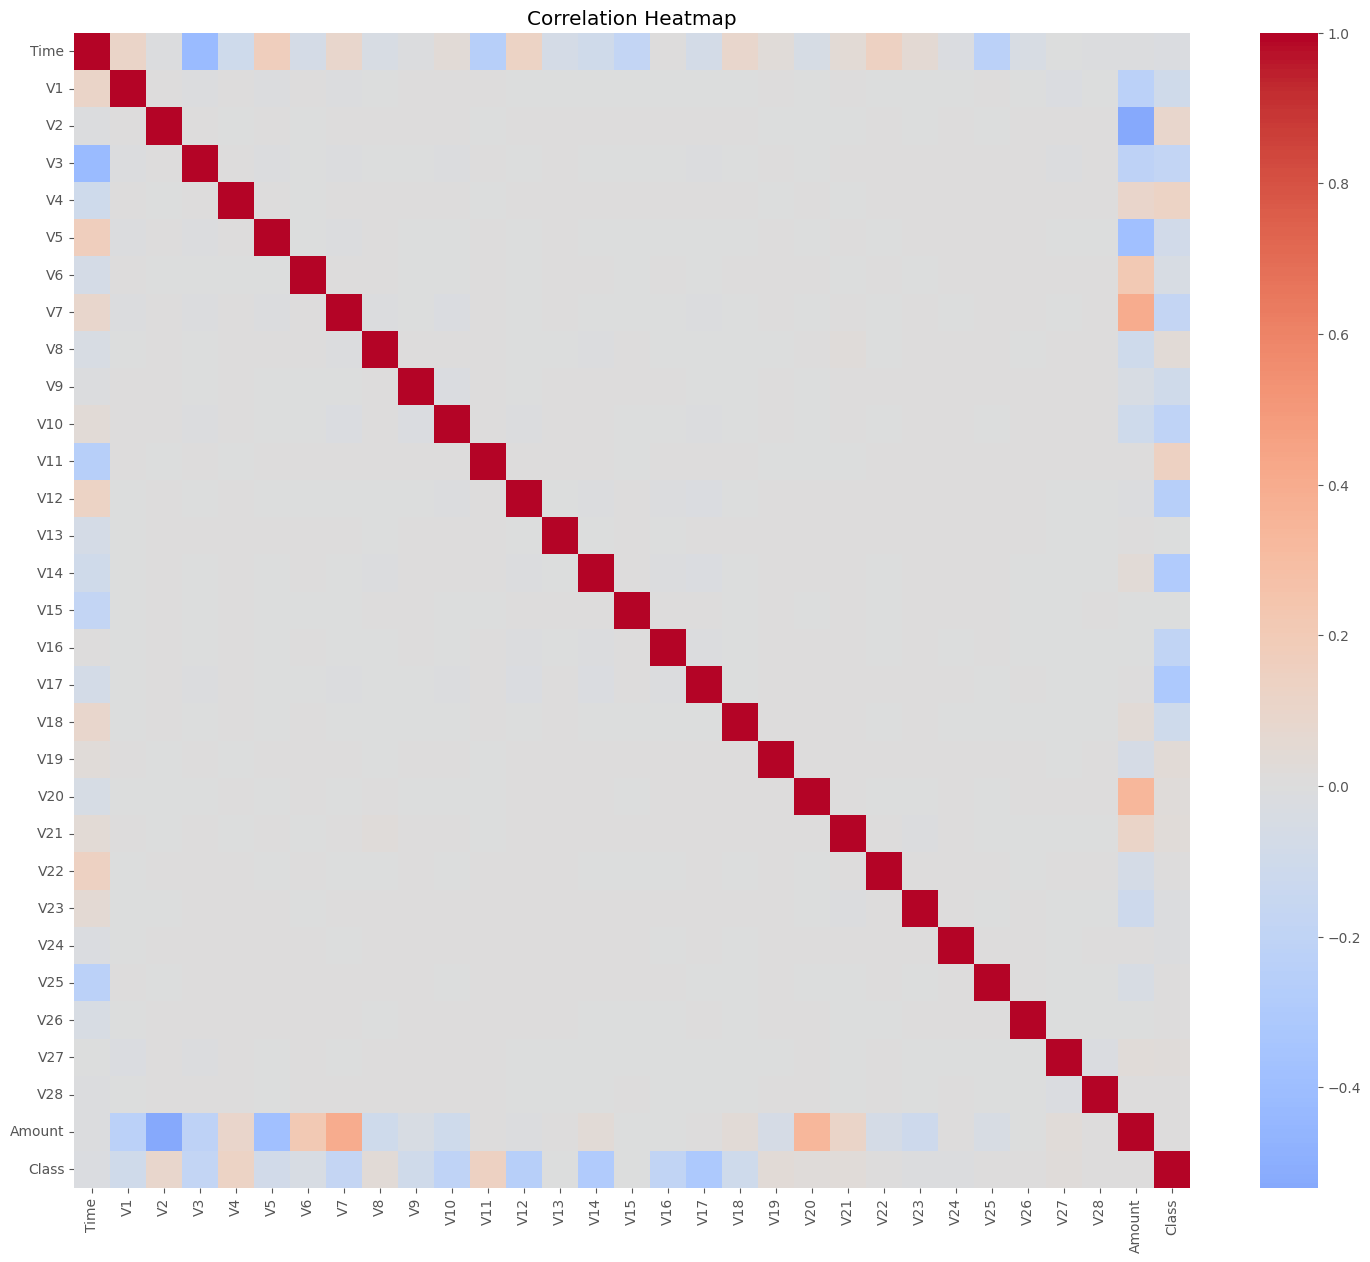

In [22]:
plt.figure(figsize=(18,15))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.savefig("../images/correlation_heatmap.png",
            dpi=300)

plt.show()

In [23]:
corr_target = corr["Class"].sort_values()

corr_target

V17      -0.313498
V14      -0.293375
V12      -0.250711
V10      -0.206971
V16      -0.187186
V3       -0.182322
V7       -0.172347
V18      -0.105340
V1       -0.094486
V9       -0.094021
V5       -0.087812
V6       -0.043915
Time     -0.012359
V24      -0.007210
V23      -0.006333
V13      -0.003897
V15      -0.003300
V25       0.003202
V26       0.004265
V22       0.004887
Amount    0.005777
V28       0.009682
V20       0.021486
V27       0.021892
V21       0.026357
V8        0.033068
V19       0.033631
V2        0.084624
V4        0.129326
V11       0.149067
Class     1.000000
Name: Class, dtype: float64

In [24]:
corr_target.tail(10)

V28      0.009682
V20      0.021486
V27      0.021892
V21      0.026357
V8       0.033068
V19      0.033631
V2       0.084624
V4       0.129326
V11      0.149067
Class    1.000000
Name: Class, dtype: float64

In [25]:
corr_target.head(10)

V17   -0.313498
V14   -0.293375
V12   -0.250711
V10   -0.206971
V16   -0.187186
V3    -0.182322
V7    -0.172347
V18   -0.105340
V1    -0.094486
V9    -0.094021
Name: Class, dtype: float64

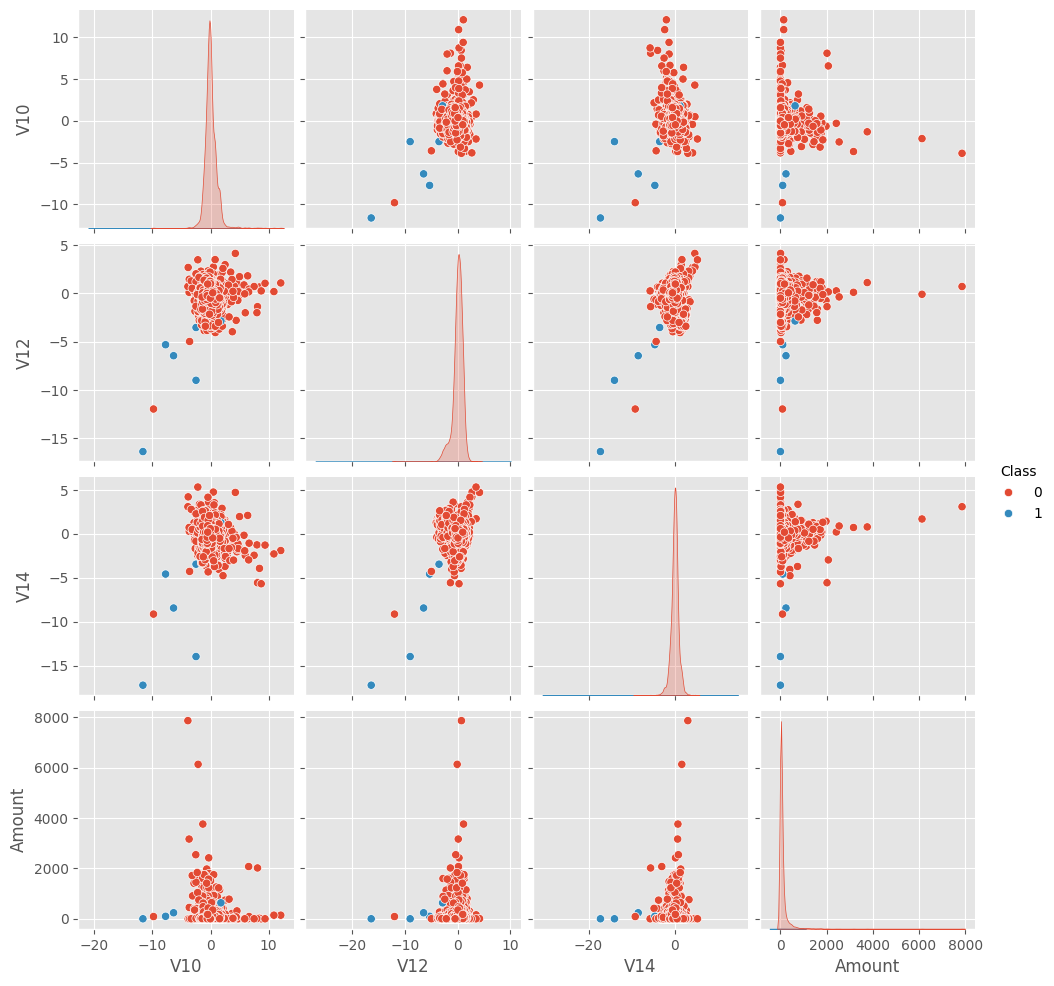

In [26]:
sample = df.sample(5000, random_state=42)

features = ["V10","V12","V14","Amount","Class"]

sns.pairplot(
    sample[features],
    hue="Class"
)

plt.savefig("../images/pairplot.png",
            dpi=300)

plt.show()

In [ ]:
Q1 = df["Amount"].quantile(0.25)

Q3 = df["Amount"].quantile(0.75)

IQR = Q3-Q1

lower = Q1-1.5*IQR

upper = Q3+1.5*IQR

outliers = df[
    (df["Amount"]<lower)|
    (df["Amount"]>upper)
]

print(len(outliers))

31685
